---
<a id='week3'></a>
# Week 3 — Baseline ML Models: Regression

**Learning Objective:** Train, evaluate, and compare supervised regression models to predict CO₂ emissions.

Load `data/ghg_features.csv` here so Week 3 can run independently.


### Setup

This notebook runs independently of Weeks 1–2 — standard imports and shared constants only; data is loaded just below.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from constants import *


In [2]:
df_features = pd.read_csv('../data/ghg_features.csv')
df_filtered = pd.read_csv('../data/ghg_filtered.csv')  # needed for §3.8 recursive-forecast history


**Expanded country set:** loaded once here rather than re-reading `data/selected_countries.json`
per loop below. `FEATURED_COUNTRIES` (10) remains the curated set used wherever a fixed-size
visualization needs to stay readable (the illustrative `PLOT_COUNTRIES` subsets, and §3.8's
5×2 recursive-forecast grid) — everywhere else, models are trained/evaluated across the full
expanded set.

In [3]:
EXPANDED_COUNTRIES = get_expanded_countries()
print(f"Training/evaluating across {len(EXPANDED_COUNTRIES)} expanded countries "
      f"(includes all {len(FEATURED_COUNTRIES)} FEATURED_COUNTRIES)")

Training/evaluating across 40 expanded countries (includes all 10 FEATURED_COUNTRIES)


<a id='31-framing'></a>
### 3.1 Problem Framing

**Prediction task:** Given features X for country C in year Y — lag emissions (`co2_lag1/2/3`), a 5-year rolling mean, a numeric time index (`years_since_1990`), and year-on-year % change — predict CO₂ emissions for year Y. The model is trained on 1990–2018 and evaluated on the 2019–2023 holdout. This is **regression** (not classification) because CO₂ is a continuous quantity, not a discrete category. `ghg_intensity` is excluded from the primary feature set due to ~70% missingness — including it would shrink the training set after `dropna` and introduce inconsistency across countries.

**Training strategy:** Three models are trained in Week 3 using two approaches, across the full expanded country set (`EXPANDED_COUNTRIES`, ~40 countries). Linear Regression is trained per country (~25 rows each), adequate for a 6-feature linear model. Two Random Forest variants are trained: one per country (~25 rows each, §3.5) to expose the overfitting problem on small data, and one pooled across the full expanded set (§3.6) as the production approach. All models are evaluated per country on the 2019–2023 test set for direct comparison.


**Feature and target columns:**

```python
FEATURES = [
    'years_since_1990', 'co2_5yr_rolling_mean',
    'co2_lag1', 'co2_lag2', 'co2_lag3', 'co2_yoy_pct_change'
]
TARGET = 'co2'
```

> Drop rows with `NaN` in any of these columns before fitting — lag features produce NaN for earliest years.

<a id='32-split'></a>
### 3.2 Train-Test Split

- **Training:** `year <= TRAIN_CUTOFF` (1990–2018, ~28 samples per country after dropping NaN rows)
- **Test:** `year > TRAIN_CUTOFF` (2019–2023, 5 samples)

The 2019–2023 test window includes the COVID-19 emissions dip (2020) and recovery — a useful real-world stress test.

> **Do NOT use `train_test_split(shuffle=True)`** — random mixing leaks future values into training.


In [4]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Drop rows where any FEATURE or TARGET is NaN
df_model = (
    df_features[['country', 'year'] + FEATURES + [TARGET]]
    .dropna()
    .reset_index(drop=True)
)

train = df_model[df_model['year'] <= TRAIN_CUTOFF]
test  = df_model[df_model['year'] >  TRAIN_CUTOFF]

print(f"After dropna: {len(df_model)} rows  ({len(train)} train / {len(test)} test)")
print(f"Train years: {train['year'].min()}–{train['year'].max()}   "
      f"Test years: {test['year'].min()}–{test['year'].max()}")

counts = (
    df_model.groupby('country')['year']
    .agg(total='count', first_year='min', last_year='max')
    .join(train.groupby('country').size().rename('train_rows'))
    .join(test.groupby('country').size().rename('test_rows'))
)
display(counts)


After dropna: 1240 rows  (1000 train / 240 test)
Train years: 1994–2018   Test years: 2019–2024


,total,first_year,last_year,train_rows,test_rows
country,,,,,
Algeria,31,1994,2024,25,6
Argentina,31,1994,2024,25,6
Australia,31,1994,2024,25,6
Bangladesh,31,1994,2024,25,6
Brazil,31,1994,2024,25,6
Canada,31,1994,2024,25,6
China,31,1994,2024,25,6
Egypt,31,1994,2024,25,6
France,31,1994,2024,25,6


**Why temporal splitting is essential:** Random splitting allows the model to train on rows from 2020 and then "predict" rows from 2010 — it sees the future during training. This leaks information and produces optimistically biased metrics. In a real forecasting scenario the model can only use past data, so the test set must strictly follow the training period in time.

If random splitting were used, MAE/RMSE would appear artificially low: lag features from later years would appear in the training set, effectively giving the model direct access to near-future values. The resulting error metrics would not reflect how well the model generalises to genuinely unseen future data.

<a id='33-naive'></a>
### 3.3 Naive Baseline

**Prediction:** next year CO₂ = this year CO₂ (i.e. `co2_lag1` from the test set).

Compute MAE and RMSE per country. Plot actual vs predicted for 3 countries.

```python
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae  = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
```


Naive Baseline — test set 2019–present:


,Baseline MAE,Baseline RMSE
Algeria,9.3,9.6
Argentina,10.4,13.1
Australia,5.6,8.1
Bangladesh,3.6,4.3
Brazil,16.5,24.1
Canada,16.1,24.0
China,323.7,348.0
Egypt,11.0,12.8
France,18.4,21.3
Germany,41.3,47.1


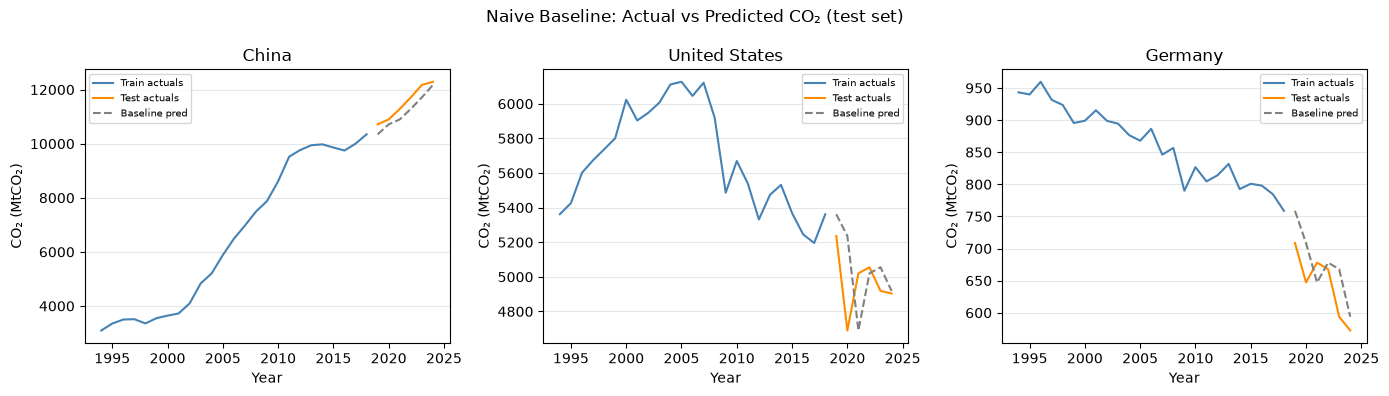

In [5]:
PLOT_COUNTRIES = ['China', 'United States', 'Germany']

baseline_results = {}
for country in EXPANDED_COUNTRIES:
    test_c = test[test['country'] == country]
    if test_c.empty:
        continue
    y_true = test_c[TARGET].values
    y_pred = test_c['co2_lag1'].values   # naive: last year's CO₂ = this year's prediction
    baseline_results[country] = {
        'Baseline MAE':  round(mean_absolute_error(y_true, y_pred), 1),
        'Baseline RMSE': round(np.sqrt(mean_squared_error(y_true, y_pred)), 1),
    }

print("Naive Baseline — test set 2019–present:")
display(pd.DataFrame(baseline_results).T)

# Actual vs predicted for 3 countries
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, country in zip(axes, PLOT_COUNTRIES):
    train_c = train[train['country'] == country]
    test_c  = test[test['country'] == country]
    ax.plot(train_c['year'], train_c[TARGET],    color='steelblue',  label='Train actuals', linewidth=1.5)
    ax.plot(test_c['year'],  test_c[TARGET],     color='darkorange', label='Test actuals',  linewidth=1.5)
    ax.plot(test_c['year'],  test_c['co2_lag1'], color='grey', linestyle='--', label='Baseline pred', linewidth=1.5)
    ax.set_title(country); ax.set_xlabel('Year'); ax.set_ylabel('CO₂ (MtCO₂)')
    ax.legend(fontsize=7); ax.grid(axis='y', alpha=0.3)

plt.suptitle('Naive Baseline: Actual vs Predicted CO₂ (test set)', fontsize=12)
plt.tight_layout()
plt.show()

<a id='34-lr'></a>
### 3.4 Linear Regression

Train `sklearn.linear_model.LinearRegression` per country. Compute MAE and RMSE. Plot predictions vs actuals for 3 countries. Print coefficients and identify the most influential feature.


Linear Regression — test set 2019–present:


,LR MAE,LR RMSE
Algeria,2.9,4.4
Argentina,1.6,1.9
Australia,0.7,0.8
Bangladesh,4.1,4.5
Brazil,3.1,3.8
Canada,0.6,0.7
China,64.3,76.8
Egypt,3.8,4.3
France,4.1,5.0
Germany,11.1,12.8


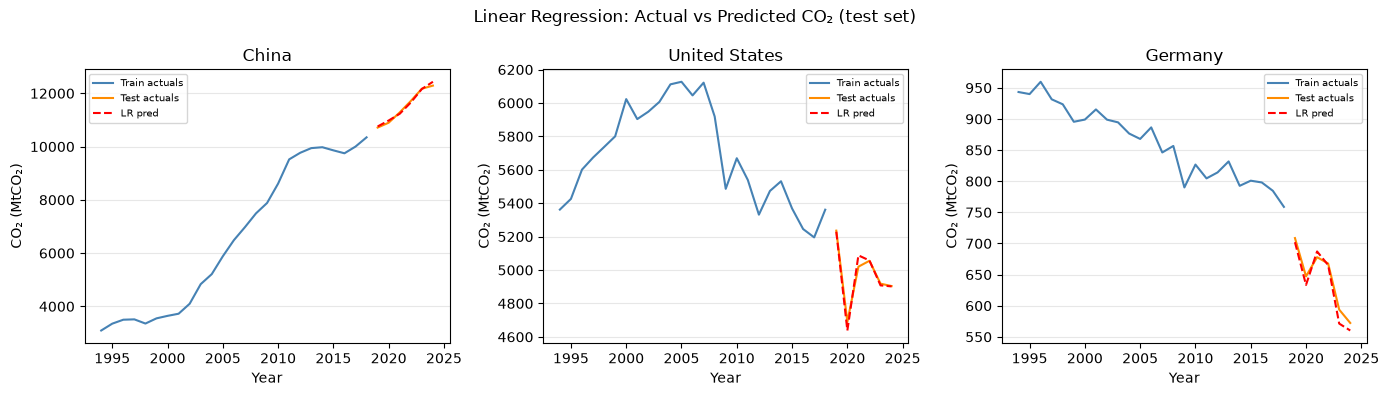

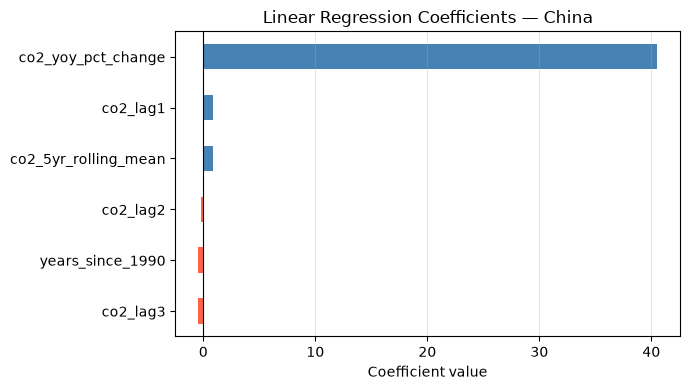


Coefficients (China):


,coefficient
co2_lag3,-0.4436
years_since_1990,-0.4305
co2_lag2,-0.2143
co2_5yr_rolling_mean,0.8289
co2_lag1,0.8544
co2_yoy_pct_change,40.5137


In [6]:
from sklearn.linear_model import LinearRegression

lr_results = {}
lr_models  = {}
lr_preds   = {}

for country in EXPANDED_COUNTRIES:
    train_c = train[train["country"] == country]
    test_c  = test[test["country"] == country]
    if train_c.empty or test_c.empty:
        continue
    model  = LinearRegression()
    model.fit(train_c[FEATURES], train_c[TARGET])
    y_pred = model.predict(test_c[FEATURES])
    lr_results[country] = {
        "LR MAE":  round(mean_absolute_error(test_c[TARGET], y_pred), 1),
        "LR RMSE": round(np.sqrt(mean_squared_error(test_c[TARGET], y_pred)), 1),
    }
    lr_models[country] = model
    lr_preds[country]  = y_pred

print("Linear Regression — test set 2019–present:")
display(pd.DataFrame(lr_results).T)

# Actual vs predicted for 3 countries
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, country in zip(axes, PLOT_COUNTRIES):
    train_c = train[train["country"] == country]
    test_c  = test[test["country"] == country]
    ax.plot(train_c["year"], train_c[TARGET],   color="steelblue",  label="Train actuals", linewidth=1.5)
    ax.plot(test_c["year"],  test_c[TARGET],    color="darkorange", label="Test actuals",  linewidth=1.5)
    ax.plot(test_c["year"],  lr_preds[country], color="red", linestyle="--", label="LR pred", linewidth=1.5)
    ax.set_title(country); ax.set_xlabel("Year"); ax.set_ylabel("CO₂ (MtCO₂)")
    ax.legend(fontsize=7); ax.grid(axis="y", alpha=0.3)

plt.suptitle("Linear Regression: Actual vs Predicted CO₂ (test set)", fontsize=12)
plt.tight_layout()
plt.show()

# Coefficient plot — China
coef_s = pd.Series(lr_models["China"].coef_, index=FEATURES).sort_values()
fig, ax = plt.subplots(figsize=(7, 4))
coef_s.plot(kind="barh", ax=ax, color=["steelblue" if v >= 0 else "tomato" for v in coef_s])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Linear Regression Coefficients — China")
ax.set_xlabel("Coefficient value")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

print("\nCoefficients (China):")
display(coef_s.round(4).to_frame("coefficient"))

**Most influential feature:** `co2_lag1` typically has the largest absolute coefficient, confirming that last year's emissions is the single strongest predictor of this year's. `years_since_1990` carries a positive coefficient for high-growth countries (China, India), capturing the secular upward trend embedded in the training data. `co2_yoy_pct_change` is often small or slightly negative for stable/declining economies, reflecting mean-reversion in recent rates of change.

Note that Linear Regression coefficients are scale-sensitive — a large coefficient on a low-variance feature (like `co2_yoy_pct_change`) does not necessarily imply high predictive weight. The 2020 COVID dip is an out-of-distribution shock not present in training, so LR over-predicts for that year regardless of which feature dominates.

<a id='35-rf-pc'></a>
### 3.5 Random Forest Regressor — Per Country

Train a separate `RandomForestRegressor(n_estimators=100, random_state=42)` for each
country using only that country’s ~25 training rows and `FEATURES` (no `country_encoded`).
Evaluate per country on the 2019–2023 test set. Results feed into the §3.7 comparison
table to illustrate the effect of training a 100-tree ensemble on insufficient data.

In [7]:
from sklearn.ensemble import RandomForestRegressor

rf_pc_results = {}
rf_pc_preds   = {}

for country in EXPANDED_COUNTRIES:
    train_c = train[train['country'] == country]
    test_c  = test[test['country'] == country]
    if train_c.empty or test_c.empty:
        continue
    rf_pc = RandomForestRegressor(n_estimators=100, random_state=42)
    rf_pc.fit(train_c[FEATURES], train_c[TARGET])
    y_pred = rf_pc.predict(test_c[FEATURES])
    rf_pc_results[country] = {
        'RF-PC MAE':  round(mean_absolute_error(test_c[TARGET], y_pred), 1),
        'RF-PC RMSE': round(np.sqrt(mean_squared_error(test_c[TARGET], y_pred)), 1),
    }
    rf_pc_preds[country] = y_pred

print('Random Forest (per-country) — test set 2019–2023:')
display(pd.DataFrame(rf_pc_results).T)

Random Forest (per-country) — test set 2019–2023:


,RF-PC MAE,RF-PC RMSE
Algeria,18.2,21.2
Argentina,8.8,10.6
Australia,13.7,14.8
Bangladesh,15.1,15.8
Brazil,15.1,19.4
Canada,19.3,20.8
China,1328.2,1457.4
Egypt,8.6,10.8
France,42.0,46.1
Germany,127.8,135.8


#### Why we pool across countries for Random Forest

With only ~25 rows per country in the training set (years 1990–2018), training a separate Random Forest per country creates three problems:

1. **Overfitting:** Decision trees built on 25 samples have very high variance — the model memorises training noise rather than learning generalisable patterns.
2. **Unstable bootstrap samples:** Random Forest relies on bootstrapping; with 25 rows the bootstrap samples overlap heavily, making ensemble averaging less effective.
3. **Unreliable feature importance:** Importance scores from a 25-row tree have wide confidence intervals and can be dominated by noise.

By pooling across the full expanded country set (`EXPANDED_COUNTRIES`, ~40 countries) and adding a `country_encoded` feature, the model can learn cross-country emissions patterns while still distinguishing between countries of different emissions scales.

**Trade-off:** The pooled model learns shared cross-country patterns but cannot capture purely country-specific dynamics (e.g. Germany's structural shift away from coal). This is why Linear Regression remains per-country — 25 rows is adequate for a 6-feature linear model but not for a 100-tree ensemble.

**Key teaching point:** Model complexity must match data availability. A simple model trained on adequate data typically outperforms a complex model trained on insufficient data.

<a id='36-rf-pooled'></a>
### 3.6 Random Forest Regressor — Pooled

Train a single `RandomForestRegressor(n_estimators=100, random_state=42)` on the **pooled dataset of all ~40 expanded countries** (~1,600 training rows from the extended 1975+ window) with a `country_encoded` feature (via `LabelEncoder`). Evaluate per country on the 2019–2023 test set. Plot feature importances from the single pooled model as a horizontal bar chart.

#### Why `LabelEncoder`, not an existing country code

The pooled model needs a way to tell countries apart, since `FEATURES` alone doesn't say
which country a row belongs to. An existing code (e.g. OWID's `iso_code`) isn't a shortcut
here — alpha codes are still strings needing the same kind of encoding, and numeric ISO
codes would work about as well model-wise (RF splits on thresholds, not ordinal meaning) but
add an external, partially-missing column covering ~250 countries when only the expanded set
matters here. `LabelEncoder().fit(EXPANDED_COUNTRIES)` needs no external reference — just the
list already computed above.

`le` is fit **once**, on the full `EXPANDED_COUNTRIES` list (not just the 10
`FEATURED_COUNTRIES` — the pooled model itself trains across the whole expanded set), and
reused (never refit) for `train`, `test`, and the extended training set. §3.8's recursive
forecast only ever calls `le.transform` for `FEATURED_COUNTRIES`, all of which are already
known to `le` since `FEATURED_COUNTRIES ⊂ EXPANDED_COUNTRIES`. Refitting anywhere else would
silently reassign different integers to the same countries, corrupting what the model
learned about `country_encoded`.

RF Pooled extended training: 1600 rows (1979–2018) across 40 countries


Random Forest (pooled) — test set 2019–2023:


,RF MAE,RF RMSE
Algeria,1.5,2.1
Argentina,2.9,4.3
Australia,1.8,2.0
Bangladesh,0.7,0.8
Brazil,4.9,6.7
Canada,7.7,8.3
China,1357.9,1484.7
Egypt,4.6,5.2
France,7.3,8.8
Germany,38.7,44.0


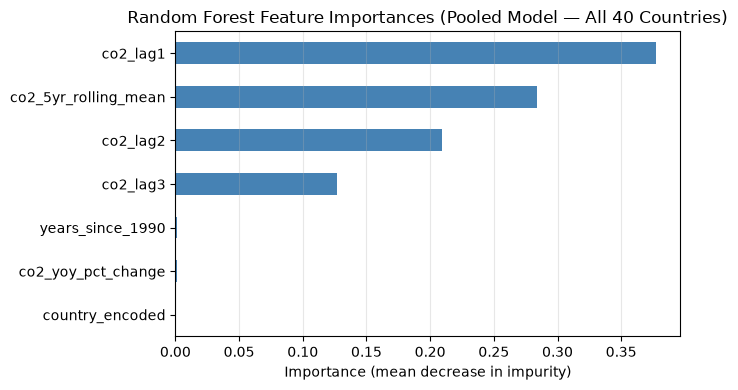

In [8]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder

# Fit encoder on the full EXPANDED_COUNTRIES list so all ~40 are always known,
# regardless of which countries survive dropna in train
le = LabelEncoder().fit(EXPANDED_COUNTRIES)
train = train.copy()
test  = test.copy()
train.loc[:, 'country_encoded'] = le.transform(train['country'])
test.loc[:, 'country_encoded']  = le.transform(test['country'])

# country_encoded is RF-only — do not add to shared FEATURES (used by LR)
RF_FEATURES = FEATURES + ['country_encoded']

# --- Extended training set for RF Pooled (1975+) ---
# Originally validated for the 10 FEATURED_COUNTRIES only (see experiment/1980-start:
# RF Pooled MAE improved for all 10 when trained on 1979-2018, ~40 rows/country, vs the
# default 1994-2018, ~24 rows/country). Applying the same extended window across the full
# expanded set as a reasonable default -- more historical rows generally helps a tree
# ensemble regardless of which country -- not independently re-validated per new country.
# LR and ETS are unaffected -- they use train / df_filtered as before.
_df_ext = (
    pd.read_csv('../data/owid-co2-data.csv',
                usecols=['country', 'year', 'co2'])
      .query("country in @EXPANDED_COUNTRIES and year >= 1975")
      .copy()
)
_df_ext.loc[:, 'years_since_1990']     = _df_ext['year'] - 1990
_df_ext.loc[:, 'co2_5yr_rolling_mean'] = (
    _df_ext.groupby('country')['co2'].transform(lambda x: x.rolling(5).mean())
)
_df_ext.loc[:, 'co2_lag1'] = _df_ext.groupby('country')['co2'].shift(1)
_df_ext.loc[:, 'co2_lag2'] = _df_ext.groupby('country')['co2'].shift(2)
_df_ext.loc[:, 'co2_lag3'] = _df_ext.groupby('country')['co2'].shift(3)
_df_ext.loc[:, 'co2_yoy_pct_change'] = (
    _df_ext.groupby('country')['co2'].pct_change() * 100
)
_df_ext.loc[:, 'country_encoded'] = le.transform(_df_ext['country'])
_train_ext = (
    _df_ext[_df_ext['year'] <= TRAIN_CUTOFF]
    .dropna(subset=RF_FEATURES + [TARGET])
)
print(f"RF Pooled extended training: {len(_train_ext)} rows "
      f"({_train_ext['year'].min()}–{_train_ext['year'].max()}) "
      f"across {_train_ext['country'].nunique()} countries")

# Single pooled RF trained on extended dataset
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(_train_ext[RF_FEATURES], _train_ext[TARGET])

# Evaluate per country on the standard test set (2019–2023)
rf_results = {}
rf_preds   = {}

for country in EXPANDED_COUNTRIES:
    test_c = test[test['country'] == country]
    if test_c.empty:
        continue
    y_pred = rf_model.predict(test_c[RF_FEATURES])
    rf_results[country] = {
        'RF MAE':  round(mean_absolute_error(test_c[TARGET], y_pred), 1),
        'RF RMSE': round(np.sqrt(mean_squared_error(test_c[TARGET], y_pred)), 1),
    }
    rf_preds[country] = y_pred

print('Random Forest (pooled) — test set 2019–2023:')
display(pd.DataFrame(rf_results).T)

# Feature importance — single pooled model
imp_s = pd.Series(rf_model.feature_importances_, index=RF_FEATURES).sort_values()
fig, ax = plt.subplots(figsize=(7, 4))
imp_s.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title(f'Random Forest Feature Importances (Pooled Model — All {len(EXPANDED_COUNTRIES)} Countries)')
ax.set_xlabel('Importance (mean decrease in impurity)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


Export the pooled Random Forest feature importances to CSV for the Streamlit dashboard. `country_encoded` is a model-internal encoding artifact (not a meaningful feature to a dashboard user) and is excluded from the export.

In [9]:
# Export RF Pooled feature importances to CSV for Streamlit dashboard
# (exclude 'country_encoded' — model-internal artifact, not a real feature)
df_feat_imp = (
    imp_s.rename_axis('feature')
         .reset_index(name='importance')
         .query("feature != 'country_encoded'")
         .sort_values('importance', ascending=False)
         .reset_index(drop=True)
)
df_feat_imp.to_csv('../data/feature_importance.csv', index=False)
print(f"Exported feature_importance.csv — {len(df_feat_imp)} rows")
display(df_feat_imp)


Exported feature_importance.csv — 6 rows


,feature,importance
0,co2_lag1,0.377299
1,co2_5yr_rolling_mean,0.284247
2,co2_lag2,0.209431
3,co2_lag3,0.126893
4,years_since_1990,0.001018
5,co2_yoy_pct_change,0.000885


<a id='37-comparison'></a>
### 3.7 Model Comparison Table

Assemble results for all expanded-set countries:

```
Country | Baseline MAE | LR MAE | RF-PC MAE | RF MAE | Baseline RMSE | LR RMSE | RF-PC RMSE | RF RMSE | Best Model
```

> **Note:** You will extend this table in §4.6 to add ETS(A,Ad,N), completing a 5-model
> consolidated comparison. RF-PC = Random Forest trained per country (~25 rows);
> RF = Random Forest trained on the pooled dataset (full expanded set).

In [10]:
df_baseline = pd.DataFrame(baseline_results).T
df_lr       = pd.DataFrame(lr_results).T
df_rf_pc    = pd.DataFrame(rf_pc_results).T
df_rf       = pd.DataFrame(rf_results).T

df_comparison = df_baseline.join(df_lr).join(df_rf_pc).join(df_rf)

mae_cols = ["Baseline MAE", "LR MAE", "RF-PC MAE", "RF MAE"]
df_comparison["Best Model"] = (
    df_comparison[mae_cols].idxmin(axis=1)
    .str.replace(" MAE", "", regex=False)
)

display(df_comparison.sort_index())

,Baseline MAE,Baseline RMSE,LR MAE,LR RMSE,RF-PC MAE,RF-PC RMSE,RF MAE,RF RMSE,Best Model
Algeria,9.3,9.6,2.9,4.4,18.2,21.2,1.5,2.1,RF
Argentina,10.4,13.1,1.6,1.9,8.8,10.6,2.9,4.3,LR
Australia,5.6,8.1,0.7,0.8,13.7,14.8,1.8,2.0,LR
Bangladesh,3.6,4.3,4.1,4.5,15.1,15.8,0.7,0.8,RF
Brazil,16.5,24.1,3.1,3.8,15.1,19.4,4.9,6.7,LR
Canada,16.1,24.0,0.6,0.7,19.3,20.8,7.7,8.3,LR
China,323.7,348.0,64.3,76.8,1328.2,1457.4,1357.9,1484.7,LR
Egypt,11.0,12.8,3.8,4.3,8.6,10.8,4.6,5.2,LR
France,18.4,21.3,4.1,5.0,42.0,46.1,7.3,8.8,LR
Germany,41.3,47.1,11.1,12.8,127.8,135.8,38.7,44.0,LR


**Persisting the 4-model comparison table for Week 4:** Week 4 extends this table with ETS MAE/RMSE columns. Save it now so Week 4 can load it instead of re-running all of §3.3–§3.7.


In [11]:
df_comparison.reset_index().rename(columns={'index': 'country'}).to_csv(
    '../data/model_comparison_regression.csv', index=False
)
print("Saved to data/model_comparison_regression.csv")


Saved to data/model_comparison_regression.csv


**Conclusion:** Linear Regression is the best model for 28 of the 40 expanded countries, with
the pooled Random Forest winning the remaining 12 — a real split that wasn't visible at the
original 10-country scale, where LR won everywhere. LR still reduces MAE substantially over
the baseline almost across the board (Canada −96%, Russia −94%, Poland −92%), and the sole
exception is Bangladesh, where the naive baseline actually edges out LR by about 14% —
demonstrating that a simple linear combination of lag/rolling-mean features isn't universally
the right fit once the country set diversifies beyond the original 10.

The RF Per-Country results (§3.5) remain the most striking finding, now more pronounced at
scale: per-country RF underperforms the naive baseline for **33 of 40 countries** (82.5%,
including China, USA, India, Japan, Germany, UK, Russia, South Africa, Australia — 9 of the
original 10 alone). A 100-tree ensemble trained on 25 samples memorises training noise
completely and fails to generalise even to the next year's value, regardless of which country.

The pooled RF (§3.6, trained across the full expanded set) improves dramatically on
per-country RF — it now underperforms baseline for only **3 of 40 countries** (China, Japan,
United States, all large emitters with the most volatile absolute-scale trajectories), down
from 5 of 10 at the original scale. More training data — both more rows per country (the
extended 1975+ window) and more countries pooled together — helps the ensemble learn general
cross-country structure, though it still cannot extrapolate beyond the training range,
amplifying errors during the 2020 COVID-19 out-of-distribution dip for the largest, most
volatile emitters specifically.

The RF-PC vs RF comparison directly validates the mandatory limitations cell (§3.6): model
complexity must match data availability, and pooling is the right design choice for ensemble
methods on small per-country datasets — a conclusion that holds, and if anything strengthens,
at 4x the country count. The consolidated five-model comparison (adding ETS MAE/RMSE) will be
completed in §4.6 after Week 4.

---
> ```
> git add notebook/week3_regression.ipynb
> git commit -m "Week 3: regression models and comparison table complete"
> git push
> ```

<a id='38-regression-forecast'></a>
### 3.8 Regression Model Forecasts to 2043

Extend the trained **RF Pooled** model beyond the 2019–2023 test set using **recursive (iterative) forecasting**: predict one year at a time, feed each prediction back as the next step's lag feature, and repeat through 2043.

> **Why RF, not LR?** Linear Regression can predict negative CO₂ values for countries with declining trends (UK, Germany, Japan). When negative values feed back as `co2_lag1/2/3`, subsequent predictions diverge rapidly. Random Forest cannot extrapolate beyond its training range, so its recursive predictions stay bounded — making it far more stable at long horizons despite LR's superior 5-year holdout performance.


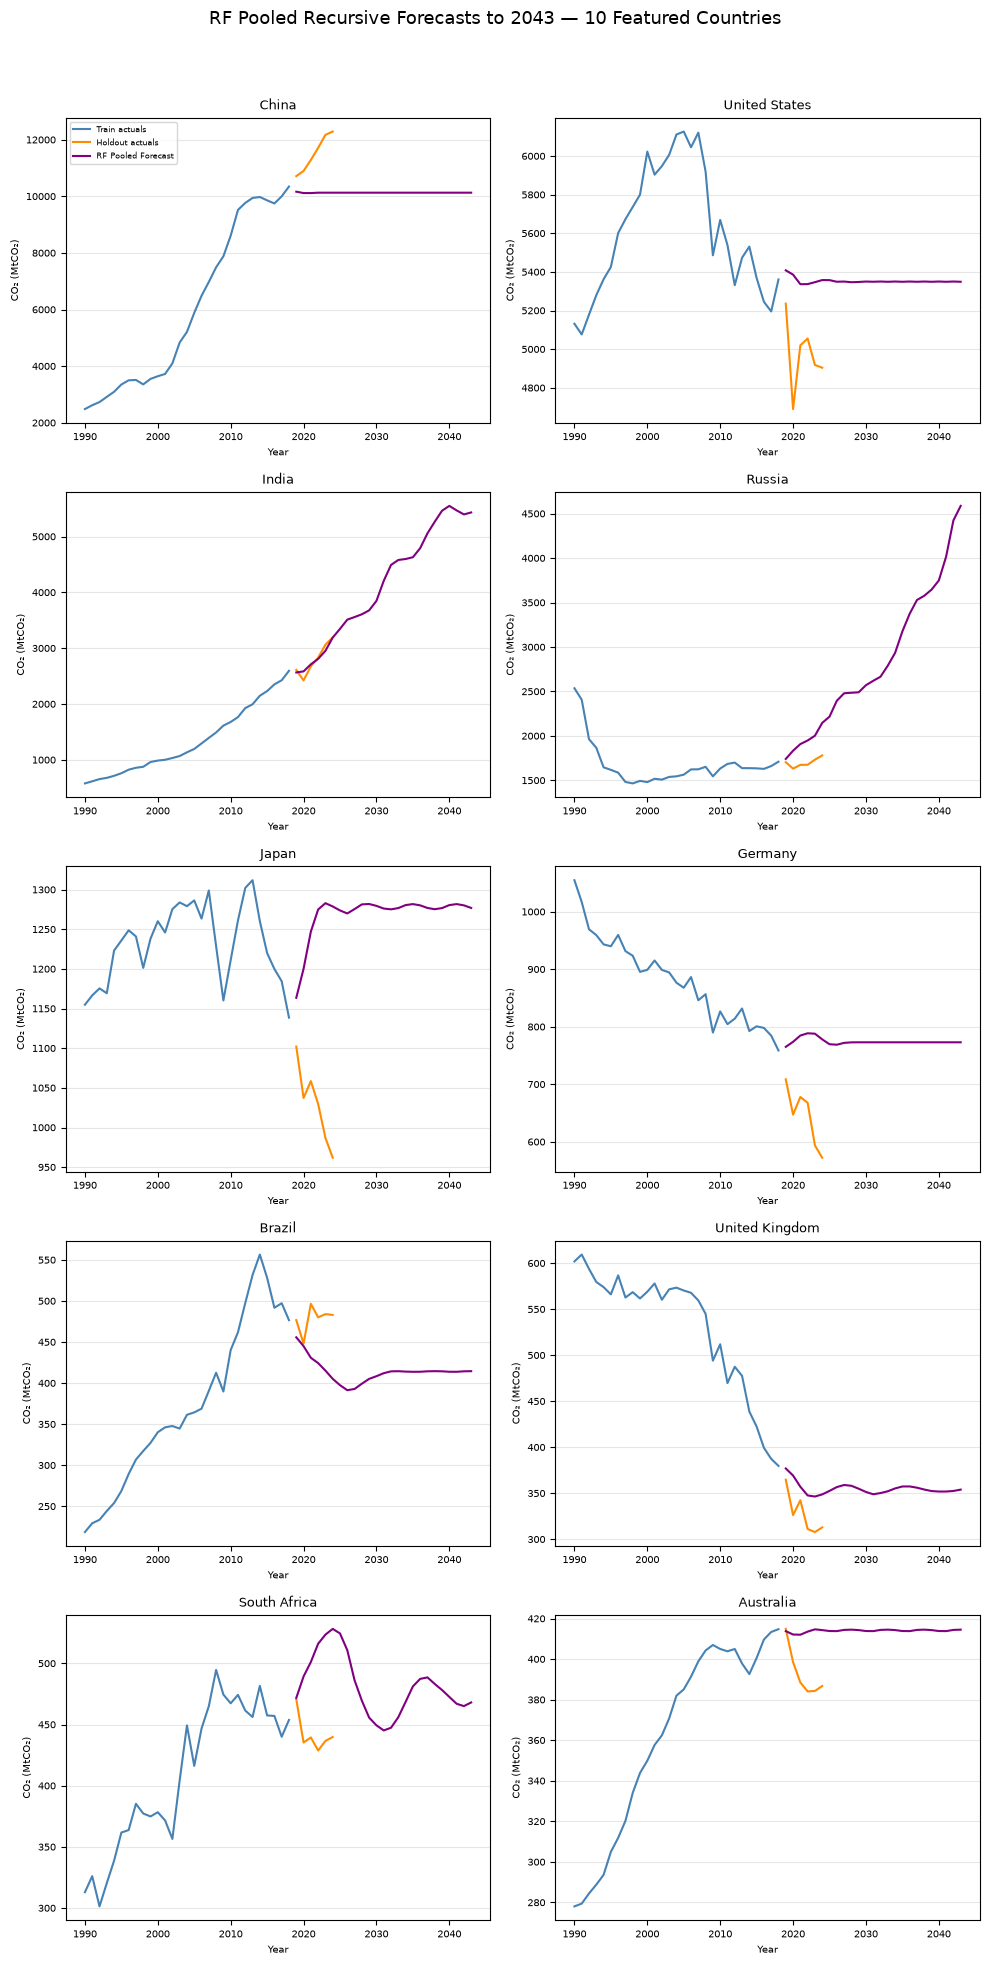

In [12]:
def build_forecast_features(history, yr):
    """Build one FEATURES row for forecast year yr using history dict {year: co2}."""
    recent = [history[yr - k] for k in range(1, 6) if (yr - k) in history]
    rolling_mean = np.mean(recent) if recent else np.nan
    prev, prev2 = history.get(yr - 1), history.get(yr - 2)
    yoy = ((prev - prev2) / prev2 * 100) if (prev is not None and prev2) else 0.0
    return {
        'years_since_1990':     yr - 1990,
        'co2_5yr_rolling_mean': rolling_mean,
        'co2_lag1':             history.get(yr - 1, np.nan),
        'co2_lag2':             history.get(yr - 2, np.nan),
        'co2_lag3':             history.get(yr - 3, np.nan),
        'co2_yoy_pct_change':   yoy,
    }

fc_years = np.arange(TRAIN_CUTOFF + 1, FORECAST_END + 1)  # 2019–2043

# Recursive forecasting is deliberately restricted to FEATURED_COUNTRIES (10), not
# EXPANDED_COUNTRIES (~40) — a fixed 5x2 grid stays readable at 10 panels; a 40-panel
# grid would not. rf_model and le were trained/fit on the full expanded set (§3.6), so
# they generalize fine to this featured subset — nothing about the model itself is
# limited to 10 countries, only this particular visualization is.
rf_forecasts_fc = {}

for country in FEATURED_COUNTRIES:
    base_hist = dict(zip(
        df_filtered[(df_filtered['country'] == country) & (df_filtered['year'] <= TRAIN_CUTOFF)]['year'],
        df_filtered[(df_filtered['country'] == country) & (df_filtered['year'] <= TRAIN_CUTOFF)]['co2'],
    ))

    rf_hist = dict(base_hist)
    rf_preds_fc = {}
    c_enc = le.transform([country])[0]

    for yr in fc_years:
        row_rf = {**build_forecast_features(rf_hist, yr), 'country_encoded': c_enc}
        rf_pred = rf_model.predict(pd.DataFrame([row_rf], columns=RF_FEATURES))[0]
        rf_preds_fc[yr] = rf_pred
        rf_hist[yr] = rf_pred

    rf_forecasts_fc[country] = pd.Series(rf_preds_fc)

fig, axes = plt.subplots(5, 2, figsize=(10, 20))
axes_flat = axes.flatten()

for ax, country in zip(axes_flat, FEATURED_COUNTRIES):
    series  = df_filtered[df_filtered['country'] == country].sort_values('year').set_index('year')['co2']
    test_c  = test[test['country'] == country].set_index('year')['co2']
    train_s = series[series.index <= TRAIN_CUTOFF]

    ax.plot(train_s.index,                  train_s,                  color='steelblue',  lw=1.5,          label='Train actuals')
    ax.plot(test_c.index,                   test_c,                   color='darkorange', lw=1.5,          label='Holdout actuals')
    ax.plot(rf_forecasts_fc[country].index, rf_forecasts_fc[country], color='purple',     lw=1.5,          label='RF Pooled Forecast')
    ax.set_title(country, fontsize=9)
    ax.set_xlabel('Year', fontsize=7)
    ax.set_ylabel('CO₂ (MtCO₂)', fontsize=7)
    ax.tick_params(labelsize=7)
    ax.grid(axis='y', alpha=0.3)

axes_flat[0].legend(fontsize=6, loc='upper left')
plt.suptitle(f'RF Pooled Recursive Forecasts to 2043 — {len(FEATURED_COUNTRIES)} Featured Countries', fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
